Objetivo: Transformar os dados operacionais (OLTP) do sistema FatorV em um Data Warehouse (OLAP) para suportar decisões estratégicas sobre vendas e faturamento.

**Tecnologias utilizadas:**

- Linguagem: Python (Pandas para ETL).

- Origem: PostgreSQL (Sistema FatorV).

- Destino: Aiven Cloud (PostgreSQL/DW).

# Extração de Dados

Nesta etapa, conectamos ao banco de dados operacional para extrair as tabelas de Clientes, Produtos, Categorias, Fornecedores, Vendedores e Vendas.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

In [ ]:
uri = "INSIRA_SUA_URI_AQUI"

if uri.startswith("postgres://"):
  uri_final = uri.replace("postgres://", "postgresql://", 1)
else:
  uri_final = uri

In [ ]:
engine = create_engine(uri_final)

# "SELECT * FROM nome_da_tabela"
query_categoria = "SELECT * FROM categories"
query_customers = "SELECT * FROM customers"
query_products = "SELECT * FROM products"
query_sales = "SELECT * FROM sales"
query_sales_items = "SELECT * FROM sales_items"
query_sellers = "SELECT * FROM sellers"
query_suppliers = "SELECT * FROM suppliers"

df_categoria = pd.read_sql(query_categoria, engine)
df_customers = pd.read_sql(query_customers, engine)
df_products = pd.read_sql(query_products, engine)
df_sales = pd.read_sql(query_sales, engine)
df_sales_items = pd.read_sql(query_sales_items, engine)
df_sellers = pd.read_sql(query_sellers, engine)
df_suppliers = pd.read_sql(query_suppliers, engine)

# Transformação

In [ ]:
mapa_estados = {
    "Acre": ["acre", " ac ", "AC", "-ac", "/ac", "(ac)", "rio branco"],
    "Alagoas": ["alagoas", " al ", "AL", "-al", "/al", "(al)", "maceio"],
    "Amapá": ["amapá", "amapa", " ap ", "AP", "-ap", "/ap", "(ap)", "macapa"],
    "Amazonas": ["amazonas", " am ", "AM", "-am", "/am", "(am)", "manaus"],
    "Bahia": ["bahia", " ba ", "BA", "-ba", "/ba", "(ba)", "salvador", "camacari", "feira de santana"],
    "Ceará": ["ceará", "ceara", " ce ", "CE", "-ce", "/ce", "(ce)", "fortaleza"],
    "Distrito Federal": ["distrito federal", " df ", "DF", "-df", "/df", "(df)", "brasilia", "brasília"],
    "Espírito Santo": ["espírito santo", "espirito santo", " es ", "ES", "-es", "/es", "(es)", "vitoria", "vitória", "vila velha", "serra - es"],
    "Goiás": ["goiás", "goias", " go ", "GO", "-go", "/go", "(go)", "goiania", "aparecida de goiania"],
    "Maranhão": ["maranhão", "maranhao", " ma ", "MA", "-ma", "/ma", "(ma)", "sao luis"],
    "Mato Grosso": ["mato grosso", " mt ", "MT", "-mt", "/mt", "(mt)", "cuiaba"],
    "Mato Grosso do Sul": ["mato grosso do sul", " ms ", "MS", "-ms", "/ms", "(ms)", "campo grande"],
    "Minas Gerais": ["minas gerais", " mg ", "MG", "-mg", "/mg", "(mg)", "belo horizonte", "bh", "uberlandia", "contagem", "betim", "juiz de fora"],
    "Pará": ["pará", "para ", " pa ", "PA", "-pa", "/pa", "(pa)", "belem"],
    "Paraíba": ["paraíba", "paraiba", " pb ", "PB", "-pb", "/pb", "(pb)", "joao pessoa"],
    "Paraná": ["paraná", "parana", " pr ", "PR", "-pr", "/pr", "(pr)", "curitiba", "londrina", "maringa", "sao jose dos pinhais"],
    "Pernambuco": ["pernambuco", " pe ", "PE", "-pe", "/pe", "(pe)", "recife", "jaboatao", "olinda"],
    "Piauí": ["piauí", "piaui", " pi ", "PI", "-pi", "/pi", "(pi)", "teresina"],
    "Rio de Janeiro": ["rio de janeiro", " rj ", "RJ", "-rj", "/rj", "(rj)", "niteroi", "niterói", "duque de caxias", "nova iguacu"],
    "Rio Grande do Norte": ["rio grande do norte", " rn ", "RN", "-rn", "/rn", "(rn)", "natal"],
    "Rio Grande do Sul": ["rio grande do sul", " rs ", "RS", "-rs", "/rs", "(rs)", "porto alegre", "caxias do sul", "canoas"],
    "Rondônia": ["rondônia", "rondonia", " ro ", "RO", "-ro", "/ro", "(ro)", "porto velho"],
    "Roraima": ["roraima", " rr ", "RR", "-rr", "/rr", "(rr)", "boa vista"],
    "Santa Catarina": ["santa catarina", " sc ", "SC", "-sc", "/sc", "(sc)", "florianopolis", "blumenau", "joinville", "sao jose - sc"],
    "São Paulo": ["são paulo", "sao paulo", " sp ", "SP", " sp,", "-sp", " - sp", "/sp", "/ sp", "(sp)", "barueri", "alphaville", "osasco", "campinas", "guarulhos", "sbc", "bernardo", "santo andre", "sao caetano", "jundiai", "sorocaba", "ribeirao preto", "sao jose dos campos"],
    "Sergipe": ["sergipe", " se ", "SE", "-se", "/se", "(se)", "aracaju"],
    "Tocantins": ["tocantins", " to ", "TO", "-to", "/to", "(to)", "palmas"]
}

mapa_regioes = {
    # Norte
    "Acre": "Norte", "Amapá": "Norte", "Amazonas": "Norte",
    "Pará": "Norte", "Rondônia": "Norte", "Roraima": "Norte", "Tocantins": "Norte",

    # Nordeste
    "Alagoas": "Nordeste", "Bahia": "Nordeste", "Ceará": "Nordeste",
    "Maranhão": "Nordeste", "Paraíba": "Nordeste", "Pernambuco": "Nordeste",
    "Piauí": "Nordeste", "Rio Grande do Norte": "Nordeste", "Sergipe": "Nordeste",

    # Centro-Oeste
    "Distrito Federal": "Centro-Oeste", "Goiás": "Centro-Oeste",
    "Mato Grosso": "Centro-Oeste", "Mato Grosso do Sul": "Centro-Oeste",

    # Sudeste
    "Espírito Santo": "Sudeste", "Minas Gerais": "Sudeste",
    "Rio de Janeiro": "Sudeste", "São Paulo": "Sudeste",

    # Sul
    "Paraná": "Sul", "Rio Grande do Sul": "Sul", "Santa Catarina": "Sul"
}

def mapear_regiao(texto):
    if not texto: return "Não Informado"
    texto = str(texto).lower().strip()

    for estado, alias_list in mapa_estados.items():
        if any(alias.lower().strip() in texto for alias in alias_list):
            return mapa_regioes.get(estado)

    return "Não Identificado"

In [ ]:
def upper_case_df(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.upper()
    return df

Deixando as colunas em maiusculo

In [ ]:
df_categoria = upper_case_df(df_categoria)
df_customers = upper_case_df(df_customers)
df_products = upper_case_df(df_products)
df_sellers = upper_case_df(df_sellers)
df_suppliers = upper_case_df(df_suppliers)

Criação dos estados

In [ ]:
df_customers['region'] = df_customers['state'].apply(mapear_regiao).str.upper()
df_suppliers['region'] = df_suppliers['state'].apply(mapear_regiao).str.upper()

Calculando subtotal e adicionando na tabela

In [ ]:
df_sales_items['subtotal'] = df_sales_items['quantity'] * df_sales_items['price']

In [ ]:
display(df_customers.head())
display(df_suppliers.head())
display(df_sales_items.head())

,customer_id,customer_name,email,state,region
0,1,YASMIN MARTINS,YASMIN.MARTINS@EMAIL.COM,MS,CENTRO-OESTE
1,2,WESLEY GOMES,WESLEY.GOMES@EMAIL.COM,RR,NORTE
2,3,RAFAEL ALVES,RAFAEL.ALVES@EMAIL.COM,RN,NORDESTE
3,4,RENATA MARTINS,RENATA.MARTINS@EMAIL.COM,PR,SUL
4,5,PAULO MARTINS,PAULO.MARTINS@EMAIL.COM,PB,NORDESTE


,supplier_id,supplier_name,email,state,region
0,1,MEGA COMERCIAL,CONTATO@MEGACOMERCIAL.COM.BR,AC,NORTE
1,2,CENTRAL IMPORTS,CONTATO@CENTRALIMPORTS.COM.BR,ES,SUDESTE
2,3,TECH SUPPLY,CONTATO@TECHSUPPLY.COM.BR,SC,SUL
3,4,NOVA COMERCIAL,CONTATO@NOVACOMERCIAL.COM.BR,RJ,SUDESTE
4,5,SIGMA DISTRIBUIDORA,CONTATO@SIGMADISTRIBUIDORA.COM.BR,AC,NORTE


,item_id,sales_id,product_id,quantity,price,subtotal
0,1,1,43,2,1342.71,2685.42
1,2,1,71,3,1459.15,4377.45
2,3,2,53,1,953.36,953.36
3,4,2,6,3,302.26,906.78
4,5,3,5,1,2001.59,2001.59


Dimensão Tempo no formato pedido

In [ ]:
datas = pd.to_datetime(df_sales['date']).unique()
df_tempo = pd.DataFrame({'data_completa': datas})

df_tempo['dia'] = df_tempo['data_completa'].dt.strftime('%Y%m%d').astype(int)
df_tempo['ano'] = df_tempo  ['data_completa'].dt.year
df_tempo['trimeste'] = df_tempo  ['data_completa'].dt.quarter
df_tempo['mes'] = df_tempo  ['data_completa'].dt.month
df_tempo

,data_completa,dia,ano,trimeste,mes
0,2023-03-18,20230318,2023,1,3
1,2023-12-24,20231224,2023,4,12
2,2023-12-06,20231206,2023,4,12
3,2023-08-14,20230814,2023,3,8
4,2023-10-01,20231001,2023,4,10
...,...,...,...,...,...
561,2025-04-18,20250418,2025,2,4
562,2025-09-20,20250920,2025,3,9
563,2025-01-27,20250127,2025,1,1
564,2025-11-17,20251117,2025,4,11


#MODELO DIMENSIONAL ESTRELA

Dimensão Produto

In [ ]:
df_dim_produto = df_products.merge(df_categoria, on='category_id').merge(df_suppliers, on='supplier_id')
df_dim_produto = df_dim_produto = df_products.merge(df_categoria, on='category_id') \
                            .merge(df_suppliers, on='supplier_id')

df_dim_produto

,product_id,product_name,category_id,price,supplier_id,category_name,supplier_name,email,state,region
0,1,PROJETOR 15 DIGITAL,1,1977.81,6,ELETRÔNICOS,NOVA ATACADO,CONTATO@NOVAATACADO.COM.BR,ES,SUDESTE
1,2,HUB USB ULTRA,1,1509.91,10,ELETRÔNICOS,NORTE DISTRIBUIDORA,CONTATO@NORTEDISTRIBUIDORA.COM.BR,SE,NORDESTE
2,3,MONITOR 27 PREMIUM,1,328.59,23,ELETRÔNICOS,GLOBAL COMERCIAL,CONTATO@GLOBALCOMERCIAL.COM.BR,ES,SUDESTE
3,4,ROTEADOR ULTRA,1,1788.40,10,ELETRÔNICOS,NORTE DISTRIBUIDORA,CONTATO@NORTEDISTRIBUIDORA.COM.BR,SE,NORDESTE
4,5,DRONE DIGITAL,1,1989.19,12,ELETRÔNICOS,SIGMA SOLUÇÕES,CONTATO@SIGMASOLUCÕES.COM.BR,GO,CENTRO-OESTE
...,...,...,...,...,...,...,...,...,...,...
78,79,LIVRO DATA SCIENCE COMPLETO,15,74.12,18,LIVROS,HORIZONTE COMERCIAL,CONTATO@HORIZONTECOMERCIAL.COM.BR,MT,CENTRO-OESTE
79,80,LIVRO PYTHON PRÁTICO,15,169.06,17,LIVROS,GLOBAL DISTRIBUIDORA,CONTATO@GLOBALDISTRIBUIDORA.COM.BR,SC,SUL
80,81,LIVRO PYTHON AVANÇADO,15,148.17,14,LIVROS,DELTA COMERCIAL,CONTATO@DELTACOMERCIAL.COM.BR,AP,NORTE
81,82,LIVRO POWER BI AVANÇADO,15,154.88,10,LIVROS,NORTE DISTRIBUIDORA,CONTATO@NORTEDISTRIBUIDORA.COM.BR,SE,NORDESTE


Tabela Fato

In [ ]:
df_sales = df_sales.rename(columns={'sale_id': 'sales_id'})
df_fato = df_sales.merge(df_sales_items, on='sales_id')

df_fato = df_fato.merge(df_sellers[['seller_id', 'tx_commission']], on='seller_id')
df_fato

,sales_id,date,customer_id,seller_id,total_price,item_id,product_id,quantity,price,subtotal,tx_commission
0,1,2023-03-18,115,18,7062.87,1,43,2,1342.71,2685.42,8
1,1,2023-03-18,115,18,7062.87,2,71,3,1459.15,4377.45,8
2,2,2023-12-24,62,19,1860.14,3,53,1,953.36,953.36,4
3,2,2023-12-24,62,19,1860.14,4,6,3,302.26,906.78,4
4,3,2023-12-06,167,5,2233.45,5,5,1,2001.59,2001.59,6
...,...,...,...,...,...,...,...,...,...,...,...
2007,798,2025-04-01,49,19,738.63,2008,83,3,188.33,564.99,4
2008,799,2025-12-18,156,7,3981.05,2009,10,1,3981.05,3981.05,10
2009,800,2025-11-27,104,4,6690.86,2010,18,1,1460.12,1460.12,8
2010,800,2025-11-27,104,4,6690.86,2011,2,1,1362.60,1362.60,8


Calcular o valor em dinheiro da comissão

In [ ]:
df_fato['valor_comissao'] = (df_fato['subtotal'] * df_fato['tx_commission']) / 100

df_fato['date_id'] = pd.to_datetime(df_fato['date']).dt.strftime('%Y%m%d').astype(int)
df_fato

,sales_id,date,customer_id,seller_id,total_price,item_id,product_id,quantity,price,subtotal,tx_commission,valor_comissao,date_id
0,1,2023-03-18,115,18,7062.87,1,43,2,1342.71,2685.42,8,214.8336,20230318
1,1,2023-03-18,115,18,7062.87,2,71,3,1459.15,4377.45,8,350.1960,20230318
2,2,2023-12-24,62,19,1860.14,3,53,1,953.36,953.36,4,38.1344,20231224
3,2,2023-12-24,62,19,1860.14,4,6,3,302.26,906.78,4,36.2712,20231224
4,3,2023-12-06,167,5,2233.45,5,5,1,2001.59,2001.59,6,120.0954,20231206
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007,798,2025-04-01,49,19,738.63,2008,83,3,188.33,564.99,4,22.5996,20250401
2008,799,2025-12-18,156,7,3981.05,2009,10,1,3981.05,3981.05,10,398.1050,20251218
2009,800,2025-11-27,104,4,6690.86,2010,18,1,1460.12,1460.12,8,116.8096,20251127
2010,800,2025-11-27,104,4,6690.86,2011,2,1,1362.60,1362.60,8,109.0080,20251127


In [ ]:
df_fato_vendas = df_fato[[
    'date_id',
    'sales_id',
    'customer_id',
    'product_id',
    'seller_id',
    'quantity',
    'price',
    'subtotal',
    'valor_comissao'
]]

display(df_fato_vendas.head())

,date_id,sales_id,customer_id,product_id,seller_id,quantity,price,subtotal,valor_comissao
0,20230318,1,115,43,18,2,1342.71,2685.42,214.8336
1,20230318,1,115,71,18,3,1459.15,4377.45,350.1960
2,20231224,2,62,53,19,1,953.36,953.36,38.1344
3,20231224,2,62,6,19,3,302.26,906.78,36.2712
4,20231206,3,167,5,5,1,2001.59,2001.59,120.0954


Tratamento dos dados das tabelas novas

In [ ]:
df_dim_produto = df_products.merge(df_categoria, on='category_id') \
                            .merge(df_suppliers, on='supplier_id')

df_dim_produto = df_dim_produto[['product_id','product_name','category_name','supplier_id','state','region']]

In [ ]:
df_dim_cliente = df_customers[['customer_id','customer_name','state','region']].drop_duplicates()

In [ ]:
df_dim_fornecedor = df_suppliers[['supplier_id','supplier_name','state','region']].drop_duplicates()

In [ ]:
df_fato_vendas = df_fato_vendas.drop_duplicates()

# Carga de Dados (Load)

In [ ]:
from sqlalchemy import create_engine

uri_dw = "DATABASE_URL"

if uri_dw.startswith("postgres://"):
  uri_final_dw = uri_dw.replace("postgres://", "postgresql://", 1)
else:
  uri_final_dw = uri_dw

engine_dw = create_engine(uri_final_dw)

print("A iniciar a carga das Dimensões...")

df_tempo.to_sql('dim_tempo', engine_dw, if_exists='replace', index=False)
df_dim_produto.to_sql('dim_produto', engine_dw, if_exists='replace', index=False)
df_customers.to_sql('dim_cliente', engine_dw, if_exists='replace', index=False)
df_sellers.to_sql('dim_vendedor', engine_dw, if_exists='replace', index=False)
df_suppliers.to_sql('dim_fornecedor', engine_dw, if_exists='replace', index=False)
print("A iniciar a carga da Tabela Fato...")
df_fato_vendas.to_sql('fato_vendas', engine_dw, if_exists='replace', index=False)

print("\nCarga no Data Warehouse concluída com sucesso! ")

A iniciar a carga das Dimensões...
A iniciar a carga da Tabela Fato...

Carga no Data Warehouse concluída com sucesso! 


# Análise de Resultados

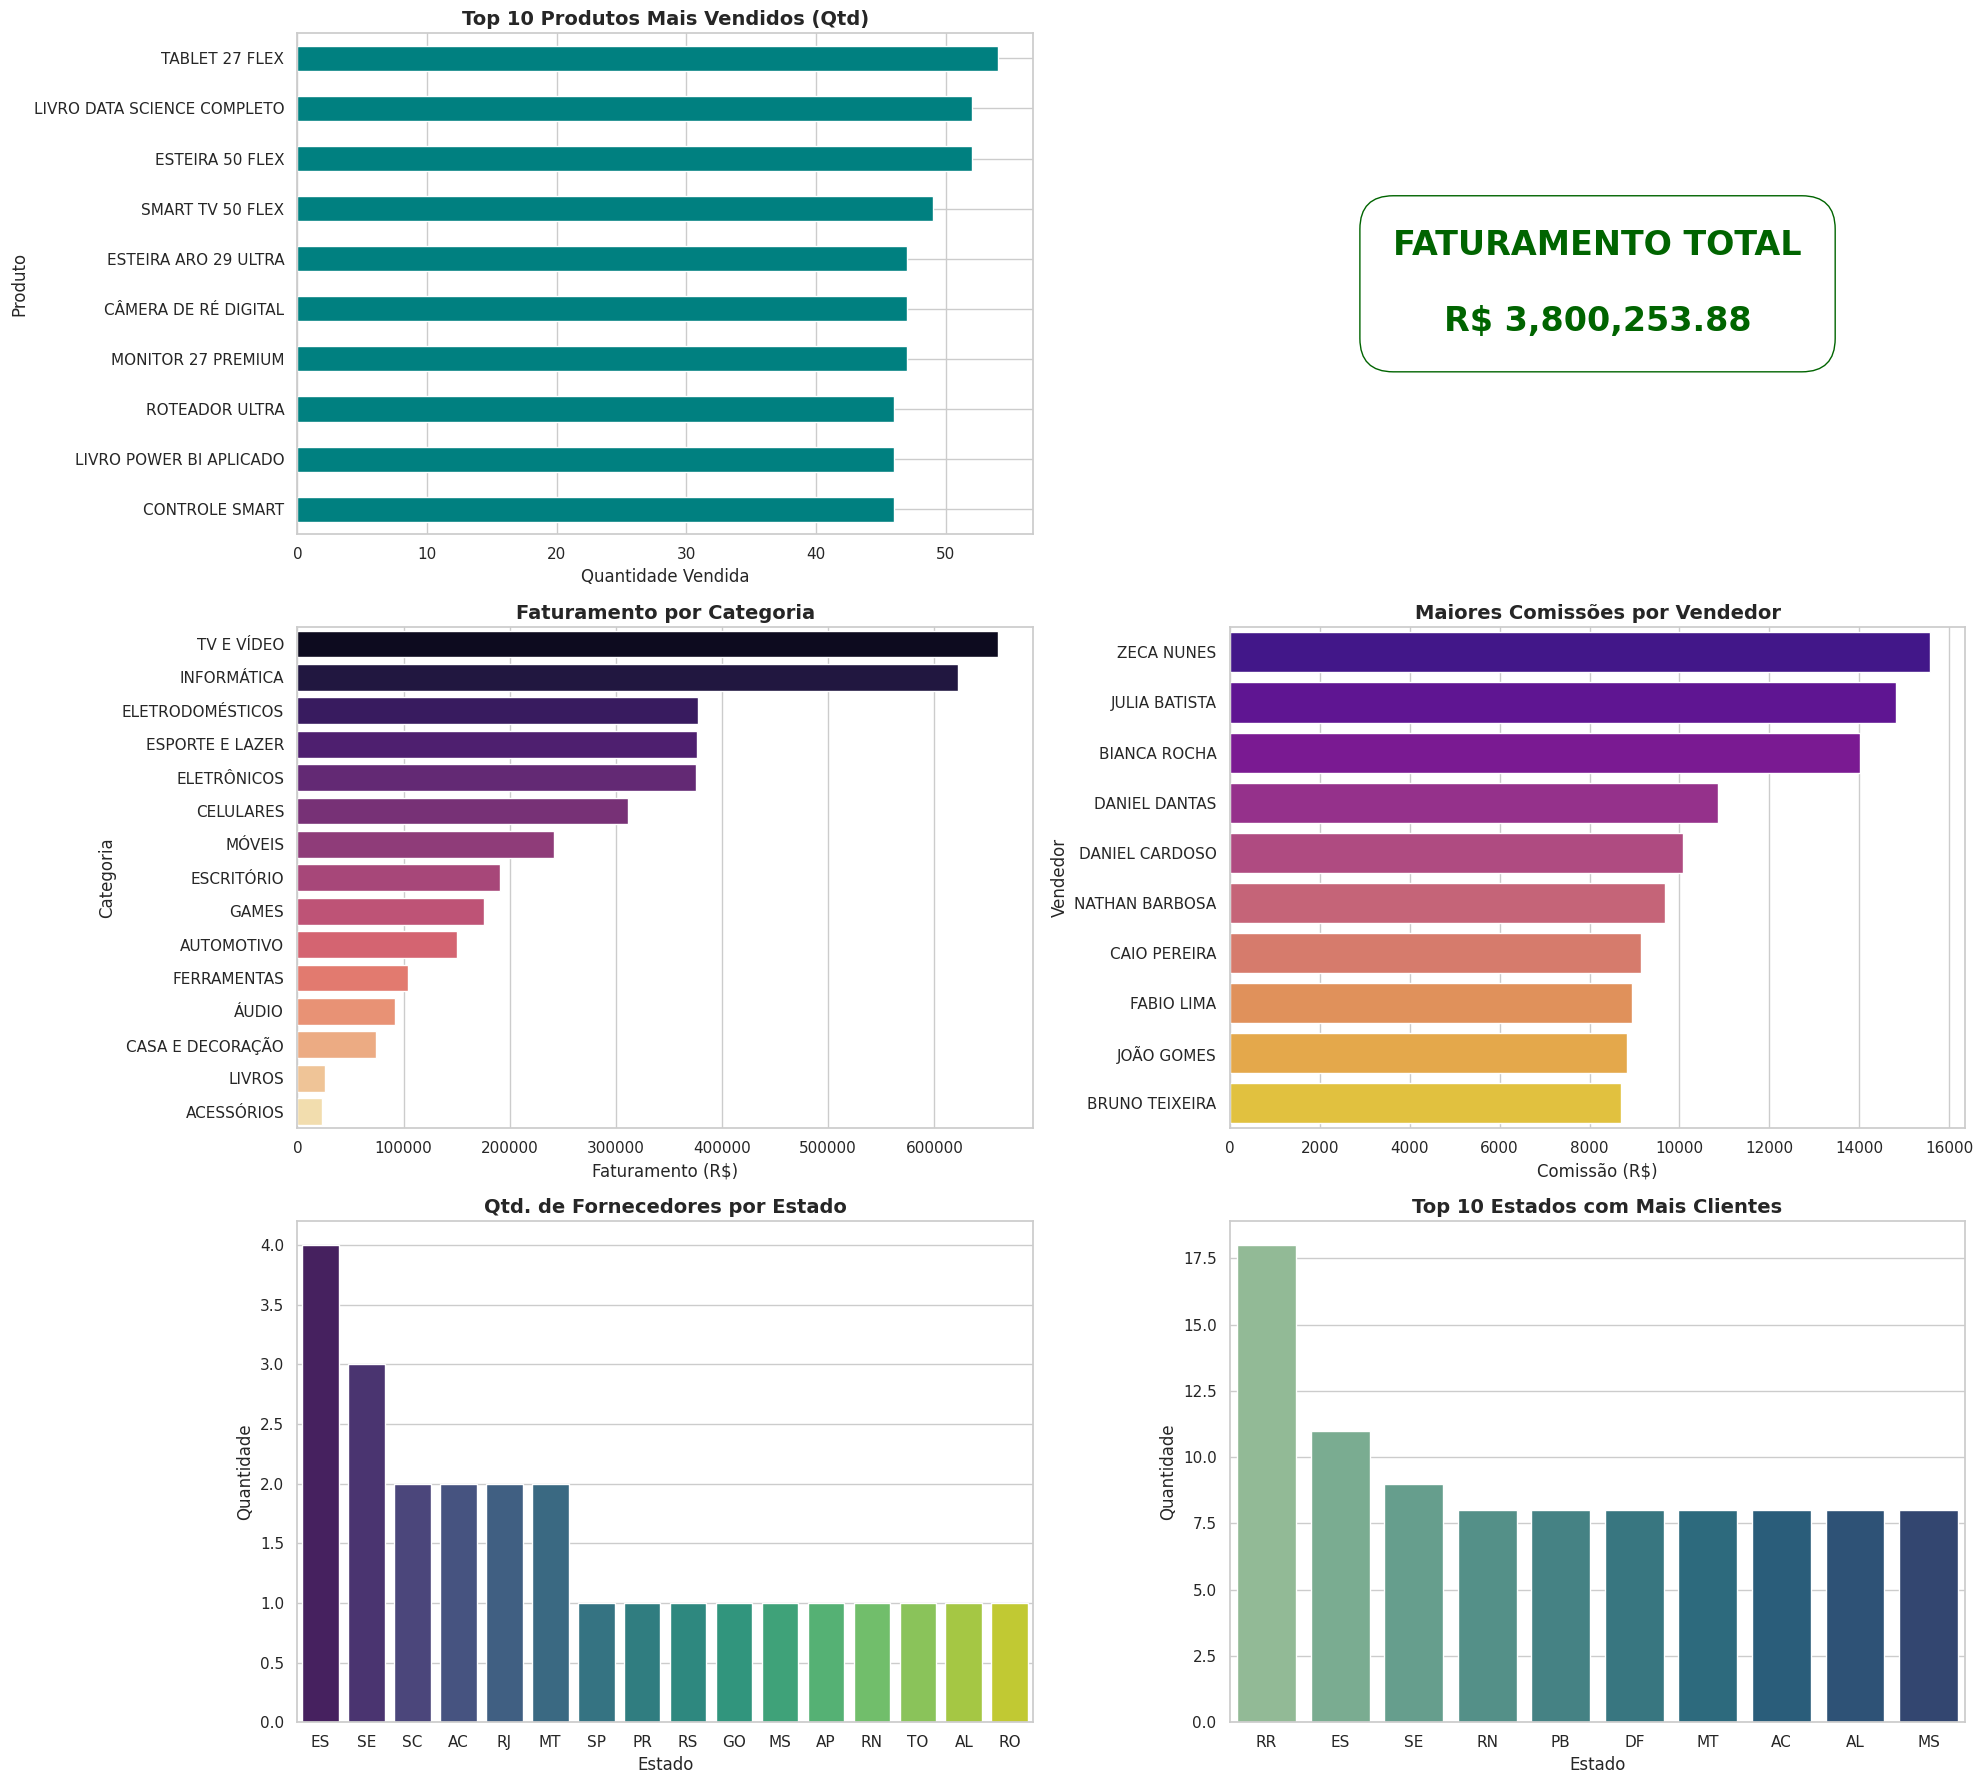

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_dw = df_fato_vendas.merge(df_dim_produto, on='product_id') \
                      .merge(df_sellers, on='seller_id')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 18))

plt.subplot(3, 2, 1)
top_produtos = df_dw.groupby('product_name')['quantity'].sum().nlargest(10).sort_values()
top_produtos.plot(kind='barh', color='teal')
plt.title('Top 10 Produtos Mais Vendidos (Qtd)', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade Vendida')
plt.ylabel('Produto')


plt.subplot(3, 2, 2)
fat_total = df_dw['subtotal'].sum()
plt.text(0.5, 0.5, f'FATURAMENTO TOTAL\n\nR$ {fat_total:,.2f}',
         fontsize=24, ha='center', va='center', fontweight='bold', color='darkgreen',
         bbox=dict(facecolor='white', edgecolor='darkgreen', boxstyle='round,pad=1'))
plt.axis('off')


plt.subplot(3, 2, 3)
fat_categoria = df_dw.groupby('category_name')['subtotal'].sum().sort_values(ascending=False)
sns.barplot(x=fat_categoria.values, y=fat_categoria.index, hue=fat_categoria.index, palette='magma', legend=False)
plt.title('Faturamento por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria')


plt.subplot(3, 2, 4)
top_comissoes = df_dw.groupby('seller_name')['valor_comissao'].sum().nlargest(10).sort_values(ascending=False)
sns.barplot(x=top_comissoes.values, y=top_comissoes.index, hue=top_comissoes.index, palette='plasma', legend=False)
plt.title('Maiores Comissões por Vendedor', fontsize=14, fontweight='bold')
plt.xlabel('Comissão (R$)')
plt.ylabel('Vendedor')


plt.subplot(3, 2, 5)
forn_estado = df_suppliers['state'].value_counts()
sns.barplot(x=forn_estado.index, y=forn_estado.values, hue=forn_estado.index, palette='viridis', legend=False)
plt.title('Qtd. de Fornecedores por Estado', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade')
plt.xlabel('Estado')


plt.subplot(3, 2, 6)
cli_estado = df_customers['state'].value_counts().nlargest(10)
sns.barplot(x=cli_estado.index, y=cli_estado.values, hue=cli_estado.index, palette='crest', legend=False)
plt.title('Top 10 Estados com Mais Clientes', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade')
plt.xlabel('Estado')


plt.tight_layout()
plt.show()